# Wallermat
_Walmart runs several promotional markdown events throughout the year. These 
markdowns precede prominent holidays, the four largest of all, which are the 
Super Bowl, Labour Day, Thanksgiving, and Christmas. The weeks including these 
holidays are weighted five times higher in the evaluation than non-holiday weeks. 
Part of the challenge presented by this assignment is modeling the effects of 
markdowns on these holiday weeks in the absence of complete/ideal historical 
data. Historical sales data for 45 Walmart stores located in different regions are 
available._

In [1]:
#First step let's put our needed modules in this project
import pandas as pd 
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt 
import warnings as wn
wn.filterwarnings("ignore")
sns.set_style("darkgrid")

In [2]:
 #Please check that your input true
walmart = pd.read_csv("C:\\Users\\LapStore\\Downloads\\walmart-sales-dataset-of-45stores.csv")
walmart

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


## __Next step is to Know the environment of our data__ 

In [3]:
# Return first 5 elements of data
print(walmart.head(),"#"*80,sep="\n")
# Discription of our data
print(walmart.describe(),"$"*80,sep="\n") 
# Some information about our data types
print(walmart.info(),"@"*80,sep="\n")
# Some check if there's nullity in data
print(f"null values = \n{walmart.isnull().sum()}","%"*80,sep="\n")
# Some check if there's any duplication
print(f"Number of duplication : {walmart.duplicated().sum()}","&"*80,sep="\n")
# Return last 5 elements of data
print(walmart.tail(),"!"*80,sep="\n")

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
################################################################################
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049  

In [4]:
walmart['Date'] = pd.to_datetime(
    walmart['Date'],
    format="%d-%m-%Y"
)


## By this check we have noticed that this data is totally cleaned and there's no any null or even any value need to get changed
#### _maybe the column who need to be checked is tempreture bassed on the kind of it "If it's kelvin so it needs to be celsius" or "If it's celsius then it's true"_
#### ___Next step is to see to analyze this data and put some columns will help us to reach our insights___

In [5]:
# First step to seprate all date 
walmart["Day"] = walmart.Date.dt.day
walmart["Month"] = walmart.Date.dt.month
walmart["Year"] = walmart.Date.dt.year
# Need to put Seasons to know which of summer or winter or even any of the 4 is the best one to make offers in this period
season_month_south = {
            12:'Winter', 1:'Winter', 2:'Winter',
            3:'Spring', 4:'Spring', 5:'Spring',
            6:'Summer', 7:'Summer', 8:'Summer',
            9:'Autumn', 10:'Autumn', 11:'Autumn'}
walmart["Season"] = walmart["Month"].map(season_month_south)
walmart

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year,Season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010,Winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010,Winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010,Winter
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010,Winter
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,28,9,2012,Autumn
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,5,10,2012,Autumn
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,12,10,2012,Autumn
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,19,10,2012,Autumn


# a) Which store has maximum sales ?
__to perform this topic we need to make pivoting between stores and sum of weekly sales to know who has the most sales between all weeks__


       Weekly_Sales
Store              
20     3.013978e+08


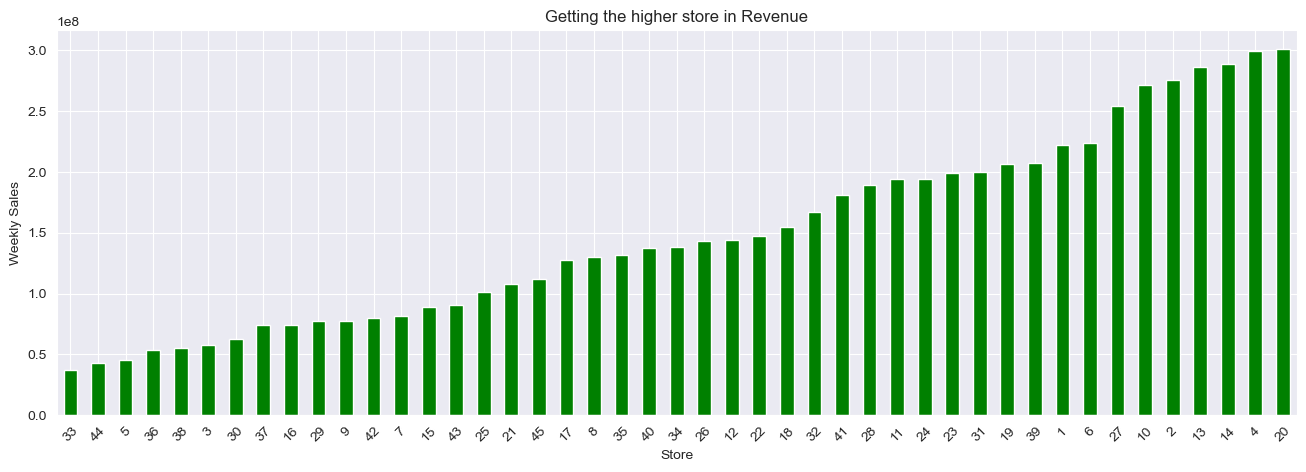

In [6]:
Store_With_Maximum_Sales = walmart.groupby("Store")["Weekly_Sales"].agg(np.sum).to_frame().sort_values(by="Weekly_Sales")
Store_With_Maximum_Sales.plot(kind="bar",rot=45,figsize=(16,5),color="Green",title="Getting the higher store in Revenue",xlabel="Store",ylabel="Weekly Sales",legend=False)
print(Store_With_Maximum_Sales[Store_With_Maximum_Sales.Weekly_Sales==max(Store_With_Maximum_Sales.Weekly_Sales)])  

### Then the highest in Weekly sales was Store number ___20___

# b) Which store has maximum standard deviation i.e., the sales vary a lot
__To perform this topic we need to pivot between Store and the variance in sales__ 

,Weekly_Sales
Store,
14,317569.949476


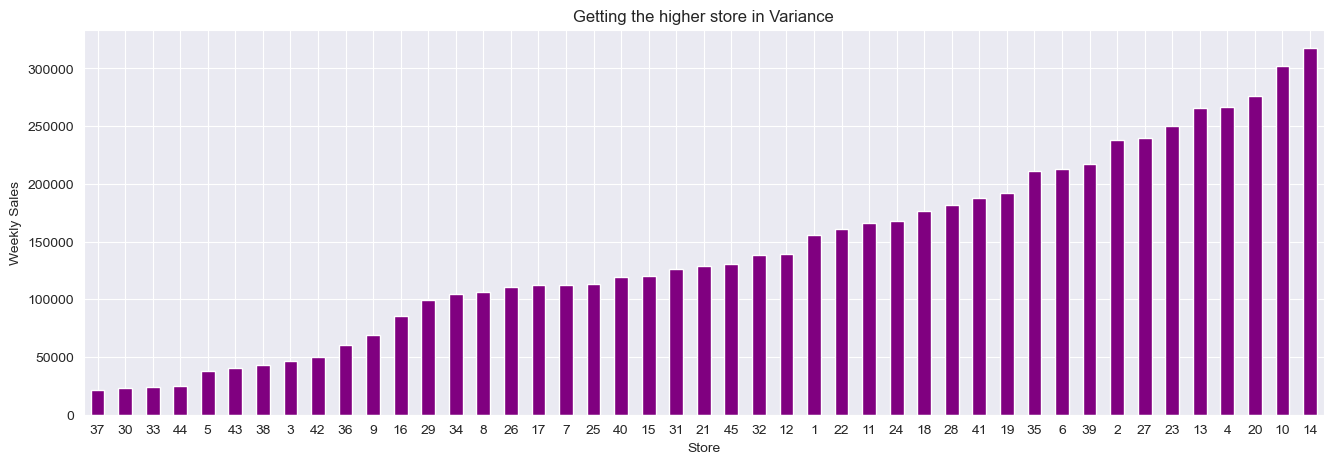

In [7]:
Store_With_Varianced_Weekly_Sales = walmart.groupby("Store")["Weekly_Sales"].agg(np.std).to_frame().sort_values(by="Weekly_Sales")
Store_With_Varianced_Weekly_Sales.plot(kind="bar",rot=360,figsize=(16,5),color="Purple",title="Getting the higher store in Variance",xlabel="Store",ylabel="Weekly Sales",legend=False)
Store_With_Varianced_Weekly_Sales[Store_With_Varianced_Weekly_Sales.Weekly_Sales==max(Store_With_Varianced_Weekly_Sales.Weekly_Sales)]

### Then the store who has a great vary in the sales is store Number ___14___

# C) Some holidays have a negative impact on sales. Find out holidays that have higher sales than the mean sales in the non-holiday season for all stores together
#### First try
**To perform that one then we need for Holiday flag , as 0 tends to non-holiday and 1 tends to holiday , and will make comparison between it and the weekly sales,Then get the stores with Negative Impact with Holidays**
#### Second Try
**Get Real Date from Kaggle and make Compare by equaling it with the same date in data and extract mean of each one then gain the insight easily**


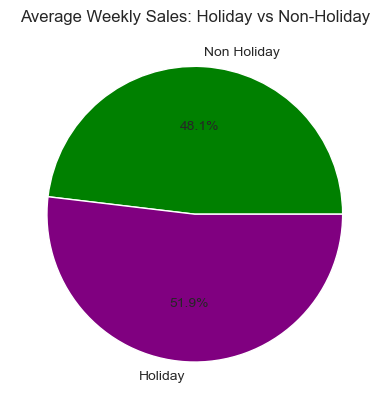

In [8]:
Holiday_Vs_Non_Holiday = walmart.groupby("Holiday_Flag")["Weekly_Sales"].agg(np.mean).to_frame()
plt.pie(data=Holiday_Vs_Non_Holiday,labels=["Non Holiday","Holiday"], x="Weekly_Sales",autopct="%0.1f%%",colors=["Green","Purple"])
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.show()

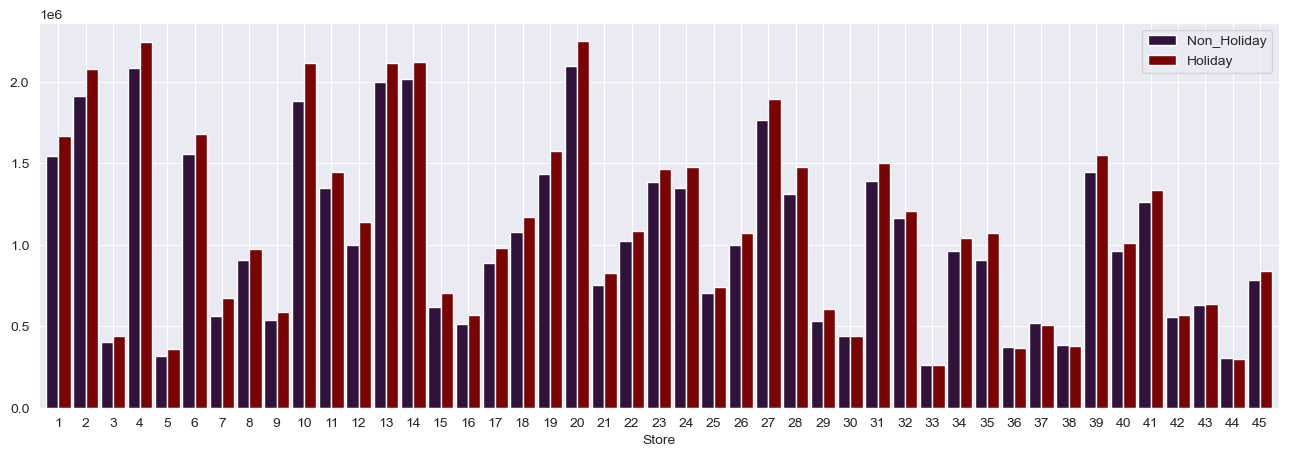

In [9]:
# First Try
Negative_Impact = pd.pivot_table(walmart,index="Store",columns="Holiday_Flag",values="Weekly_Sales",aggfunc=np.mean)
Negative_Impact.columns = ["Non_Holiday","Holiday"]
Negative_Impact.plot(kind="bar",figsize=(16,5),rot=360,width=0.9,colormap="turbo")
plt.show()

### Then The store "30,36,37,38 and 44" Have a bad impact in revenue

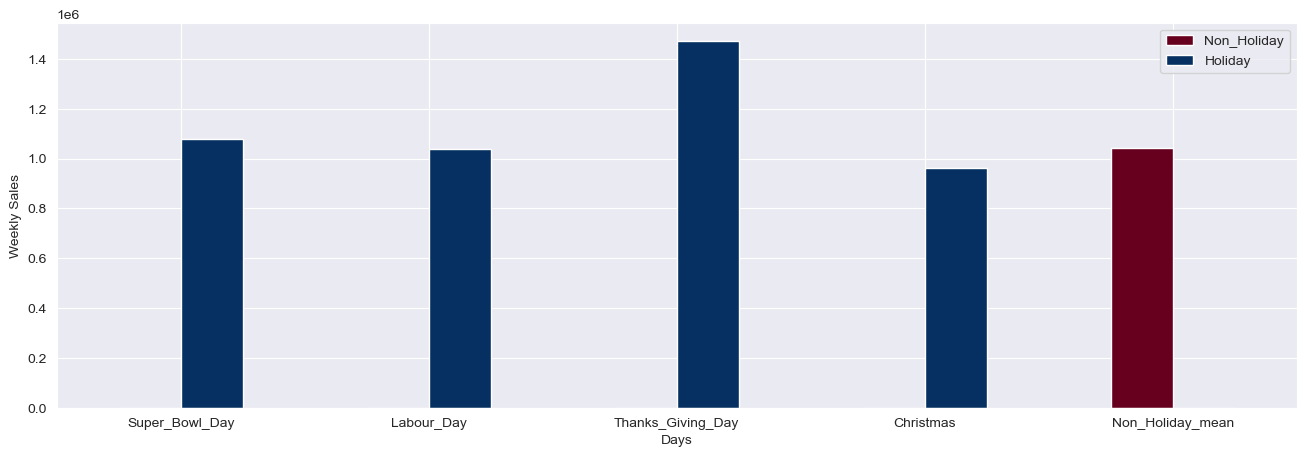

In [10]:
# Second Try
# Assign holidays in table
# Holidays
Super_Bowl = pd.to_datetime(
    ["12-02-2010","11-02-2011","10-02-2012"],
    dayfirst=True
)

Labour_Day = ["10-9-2010","9-9-2011","7-9-2012"]
ThanksGivingDay = ["26-11-2010","25-11-2011","23-11-2012"]
Christmas = ["31-12-2010","30-12-2011","28-12-2012"]
# Put it into the Walmart data
walmart["Super_Bowl_Day"] = (walmart.loc[walmart.Date.isin(Super_Bowl)])["Weekly_Sales"]
walmart["Labour_Day"] = (walmart.loc[walmart.Date.isin(Labour_Day)])["Weekly_Sales"]
walmart["Thanks_Giving_Day"]= (walmart.loc[walmart.Date.isin(ThanksGivingDay)])["Weekly_Sales"]
walmart["Christmas"]= (walmart.loc[walmart.Date.isin(Christmas)])["Weekly_Sales"]
walmart["Non_Holiday_mean"] = walmart[walmart["Holiday_Flag"]==0]["Weekly_Sales"]
Compare_Between_every_Holiday= walmart.groupby("Holiday_Flag")[["Super_Bowl_Day","Labour_Day","Thanks_Giving_Day","Christmas","Non_Holiday_mean"]].agg(np.mean).T
Compare_Between_every_Holiday.columns = ["Non_Holiday","Holiday"]
Compare_Between_every_Holiday.fillna("False Value")
Compare_Between_every_Holiday.plot(kind="bar",rot=360,ylabel="Weekly Sales",xlabel="Days",figsize=(16,5),colormap="RdBu")
plt.show()

##### __Then Notice again that the "Thank's Giving day" Was the best day in renvue, then "Super Bowl" then "Labour" , and Christmas in last__

# Grouped Column chart

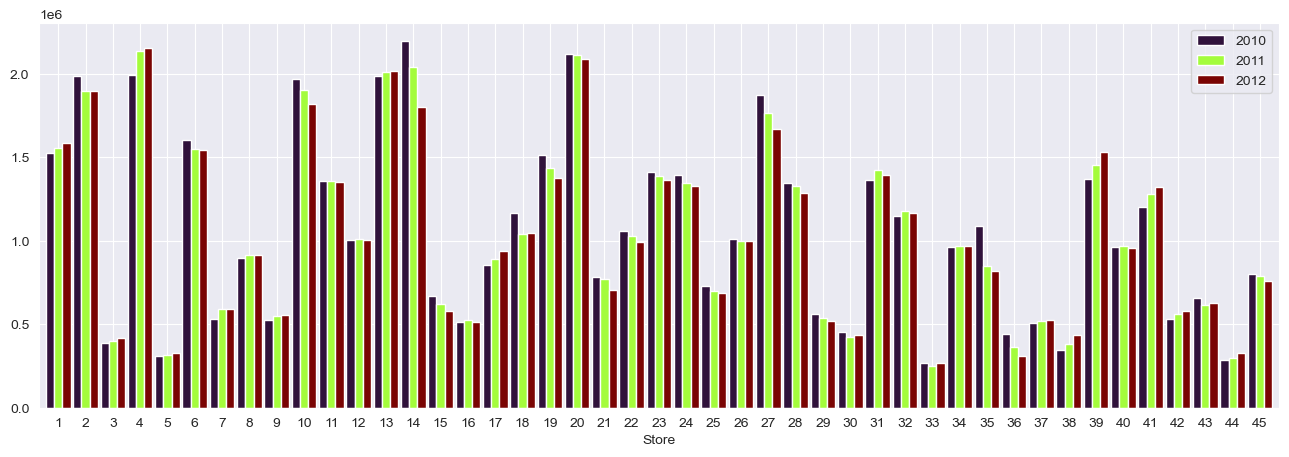

In [11]:
Negative_Impact = pd.pivot_table(walmart,index="Store",columns="Year",values="Weekly_Sales",aggfunc=np.mean)
Negative_Impact.columns = [2010,2011,2012]
Negative_Impact.plot(kind="bar",figsize=(16,5),rot=360,width=0.9,colormap="turbo")
plt.show()


### from this relation we realize that the store number 14 in 2010 was the highest mean of  sales  ,
### the store number 4 in 2011 & 2012 was the highest mean of sales 

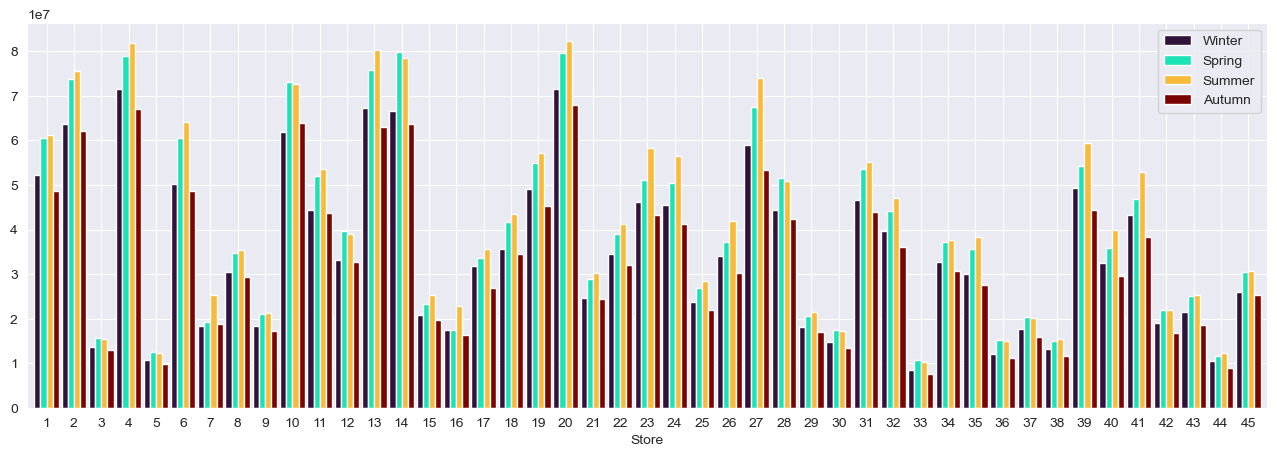

In [12]:
Negative_Impact2 = pd.pivot_table(walmart,index="Store",columns="Season",values="Weekly_Sales",aggfunc=np.sum)
Negative_Impact2.columns = ["Winter",'Spring','Summer','Autumn']
Negative_Impact2.plot(kind="bar",figsize=(16,5),rot=360,width=0.9,colormap="turbo")
plt.show()

### the store number 4 and 20 in summer that total sales are approximating

# c) visualize quantitive variables distributions

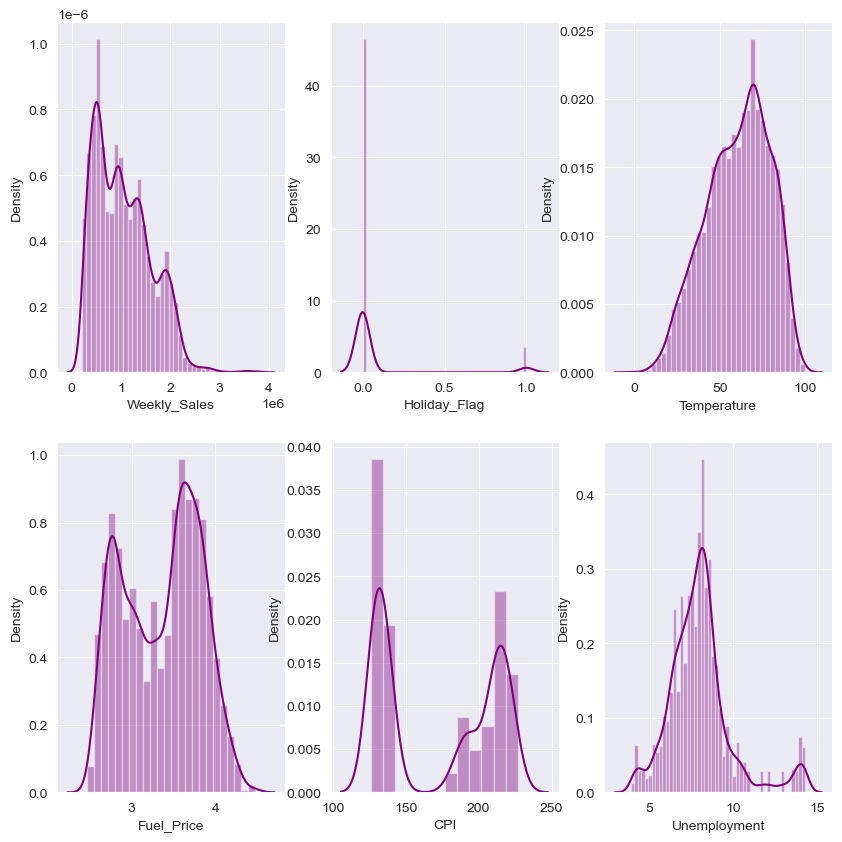

In [13]:
fig,axis=plt.subplots(nrows=2,ncols=3,figsize=(10,10))
ax =sns.distplot(walmart['Weekly_Sales'],kde=True ,ax = axis[0,0],color='purple')
ax =sns.distplot(walmart['Holiday_Flag'],kde=True ,ax = axis[0,1],color='purple')
ax =sns.distplot(walmart['Temperature'],kde=True ,ax = axis[0,2],color='purple')
ax =sns.distplot(walmart['Fuel_Price'],kde=True ,ax = axis[1,0],color='purple')
ax =sns.distplot(walmart['CPI'],kde=True ,ax = axis[1,1],color='purple')
ax =sns.distplot(walmart['Unemployment'],kde=True ,ax = axis[1,2],color='purple')

In [14]:
def LineHist(walmart, column):
    plt.figure(figsize=(8, 5))
    walmart[column].plot(kind = "hist", density = True, bins = 5,edgecolor="black") # change density to true, because KDE uses density
    walmart[column].plot(kind = "kde",color='red')
    plt.xlabel("count")
    plt.ylabel("Frequency")
    plt.title("line histogram " +column)
    plt.show()

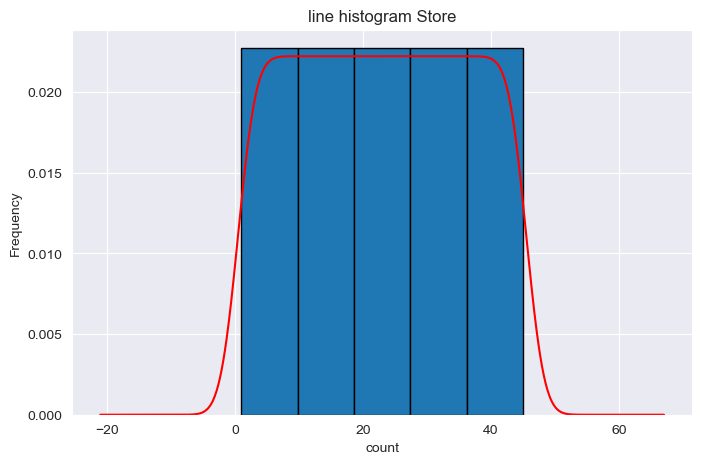

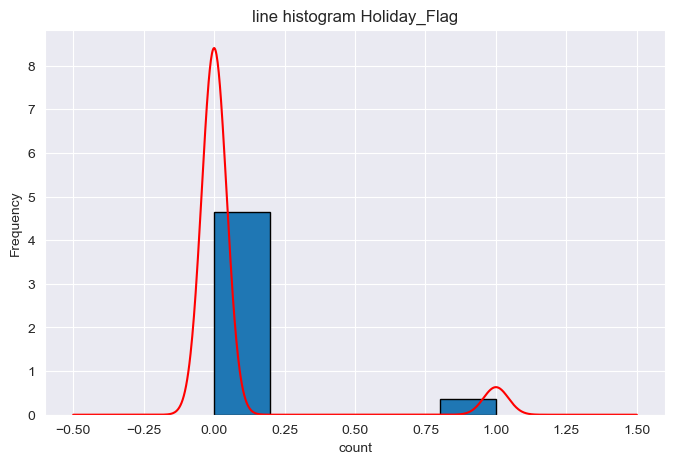

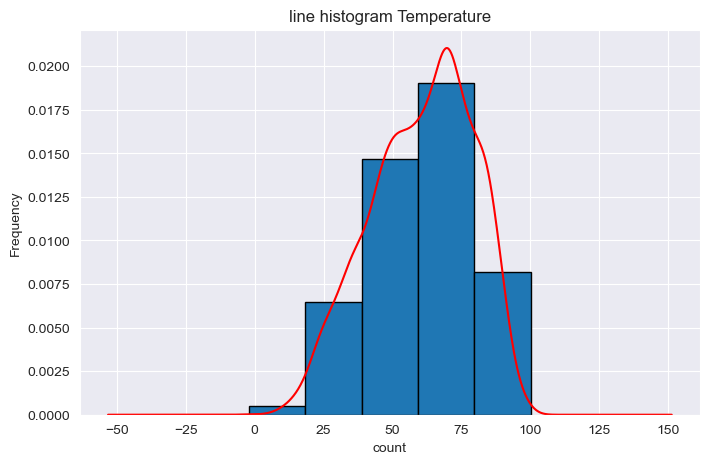

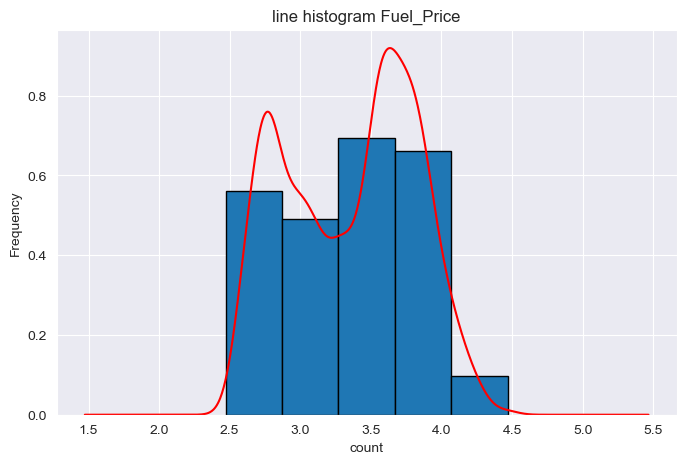

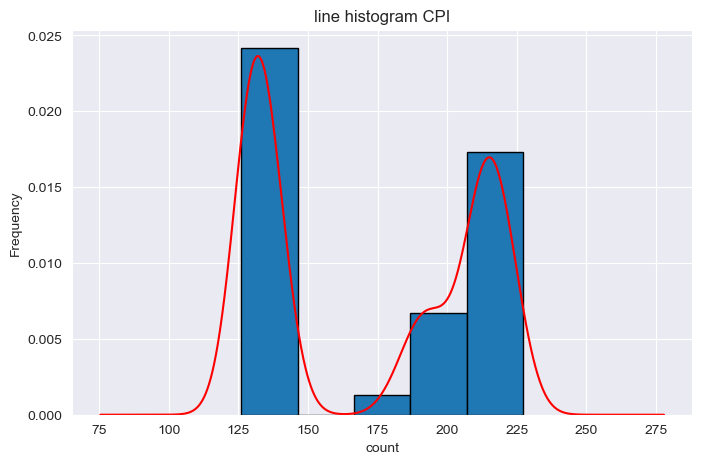

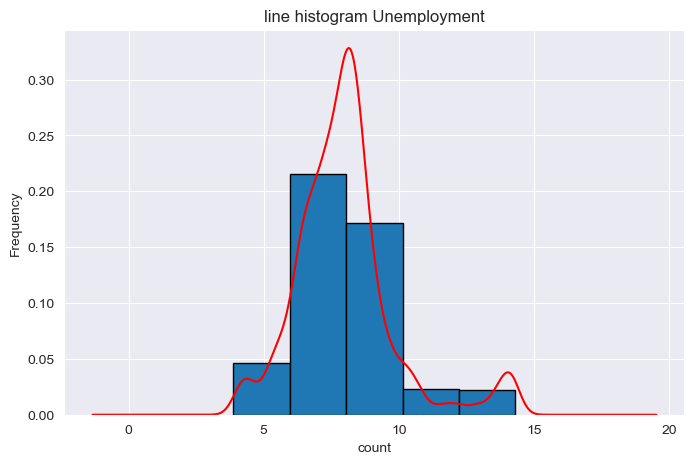

In [15]:
LineHist(walmart, 'Store')
LineHist(walmart, 'Holiday_Flag')
LineHist(walmart, 'Temperature')
LineHist(walmart, 'Fuel_Price')
LineHist(walmart, 'CPI')
LineHist(walmart, 'Unemployment')

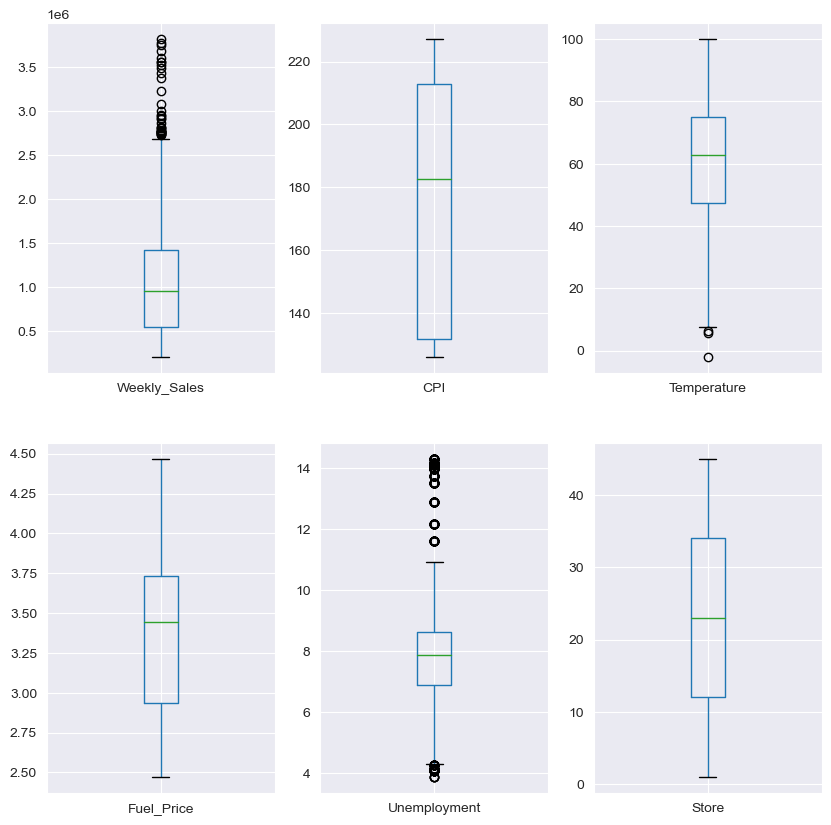

In [17]:
fig,axis=plt.subplots(nrows=2,ncols=3, figsize=(10,10))
ax=walmart.boxplot('Weekly_Sales',ax=axis[0,0])
ax=walmart.boxplot('CPI',ax=axis[0,1])
ax=walmart.boxplot('Temperature',ax=axis[0,2])
ax=walmart.boxplot('Fuel_Price',ax=axis[1,0])
ax=walmart.boxplot('Unemployment',ax=axis[1,1])
ax=walmart.boxplot('Store',ax=axis[1,2])
plt.show()

In [18]:
Q1 = walmart["Weekly_Sales"].quantile(0.25)
Q3 = walmart["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Cap the outliers
walmart["Weekly_Sales"] = np.where(
    walmart["Weekly_Sales"] > upper,
    upper,
    walmart["Weekly_Sales"]
)

# Remove rows outside the IQR limits (optional, if you want a cleaned dataset)
walmart_clean = walmart[
    (walmart["Weekly_Sales"] >= lower) &
    (walmart["Weekly_Sales"] <= upper)
]


In [19]:
Q1 = walmart["Unemployment"].quantile(0.25)
Q3 = walmart["Unemployment"].quantile(0.75)
IQR = Q3 - Q1
walmart["Unemployment"] = np.where(
    walmart["Unemployment"] > upper,
    upper,
    walmart["Unemployment"]
)

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

walmart_clean = walmart[
    (walmart["Unemployment"] >= lower) &
    (walmart["Unemployment"] <= upper)
]


# d) Provide a monthly and semester view of sales in units and give insights.

the insights of question d is from the visualization between weekly sales , Month and visualization between weekly sales , Season we realize that month 4 and season spring has heightest  weekly sales so we can increase holiday flags in this month to increase the weekly sales and do the same factors that help this month to has heightest weekly sales to the stores that has low weekly sales   

# SubPlots


### from this plot we realize that moth 4 has the  highest weekly_sales
### from this plot we realize that season spring has the highest of weekly_sales
### form this chart we realise that non holidays has the highest   weekly sales

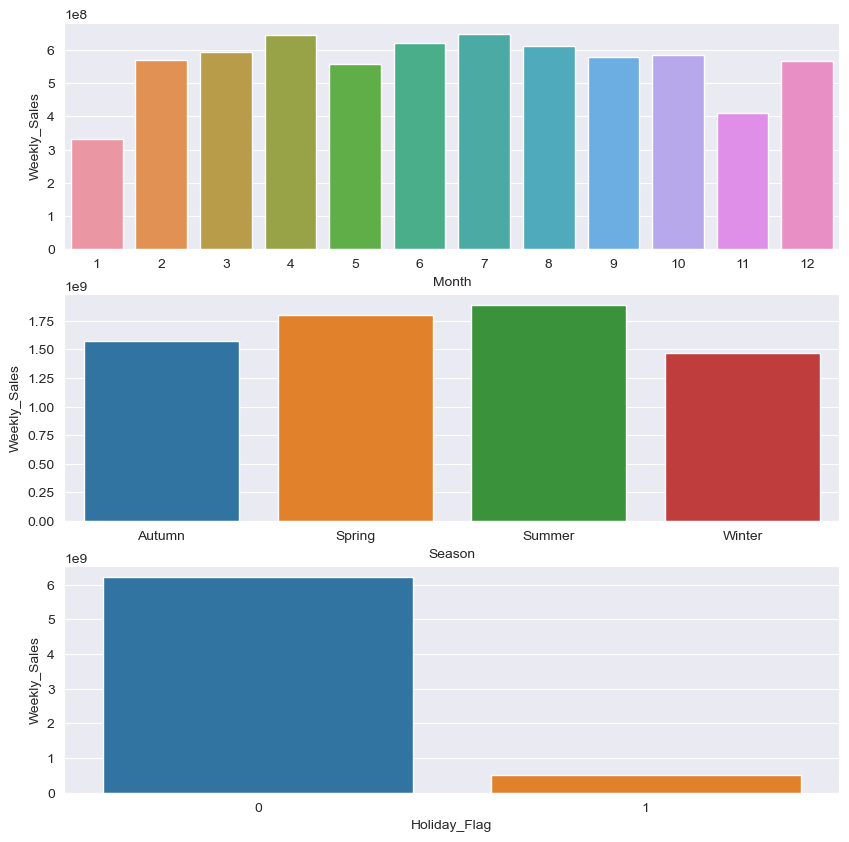

In [20]:
data = walmart.groupby("Month")['Weekly_Sales'].sum().to_frame().reset_index()
data1 = walmart.groupby("Season")['Weekly_Sales'].sum().to_frame().reset_index()
data2 = walmart.groupby("Holiday_Flag")['Weekly_Sales'].sum().to_frame().reset_index()
plt.figure(figsize = (10,10))
plt.subplot(3,1,1)
sns.barplot( y="Weekly_Sales",x="Month",data=data )
plt.subplot(3,1,2)
sns.barplot( y='Weekly_Sales',x= "Season",data=data1)
plt.subplot(3,1,3)
sns.barplot( y='Weekly_Sales',x= "Holiday_Flag",data=data2)
plt.show()

# e) Plot the relations between weekly sales vs. other numeric features and give insights.

the insights of question e is from the scatter visualization between Fuel_Price,Weekly_Sales we realize that when the intensity of fuel price increase the weekly sales go down and when the intensity of fuel price decrease the weekly sales increase so we know the the relation between weekly sales and fuel price is reverse 

from the scatter visualization between Unemployment ,Weekly_Sales we realize that when the intensity of Unemployment  increase the weekly sales go down and when the intensity of Unemployment  decrease the weekly sales increase so we know the the relation between weekly sales and Unemployment  is reverse

from this two relations we know that fuel price and unemployment impact negative on weekly salses 
so the stores that have high Unemployment and high fuel price have low weekly sales and we show that using barplots between store,Unemployment and store,fuel price

we realize from this barplots that stores 12,28,38 high Unemployment and high fuel price

so to increase the weekly sales of this stores we can make holioday flags to encourage customers to buy and decrease the cpi

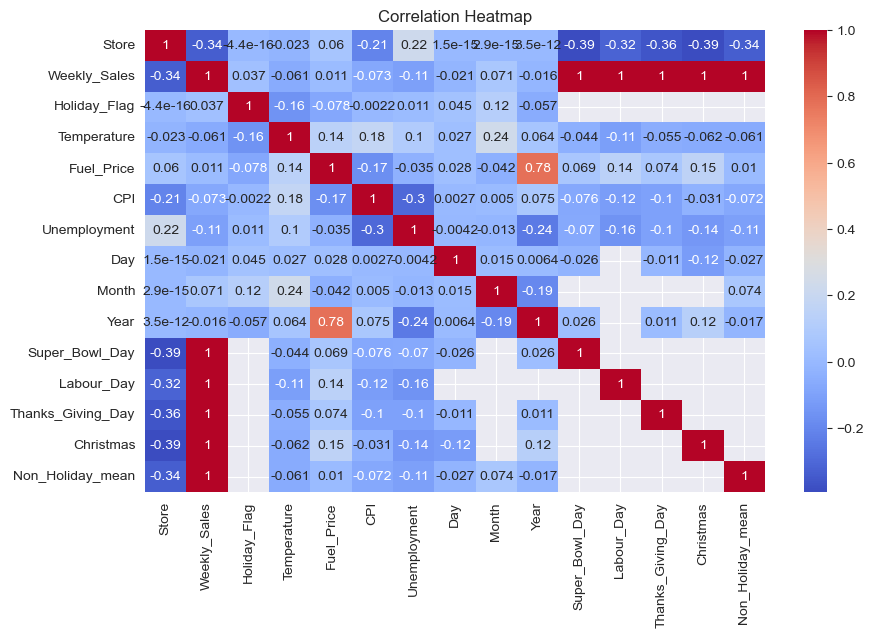

In [21]:
# اختيار الأعمدة الرقمية فقط
numeric_cols = walmart.select_dtypes(include=np.number)

# رسم heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


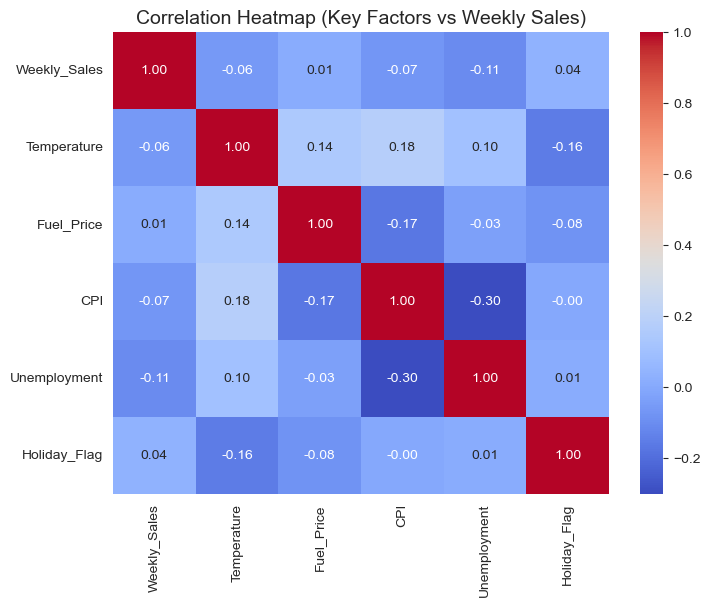

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000002A08F3D9E40> (for post_execute):


KeyboardInterrupt: 

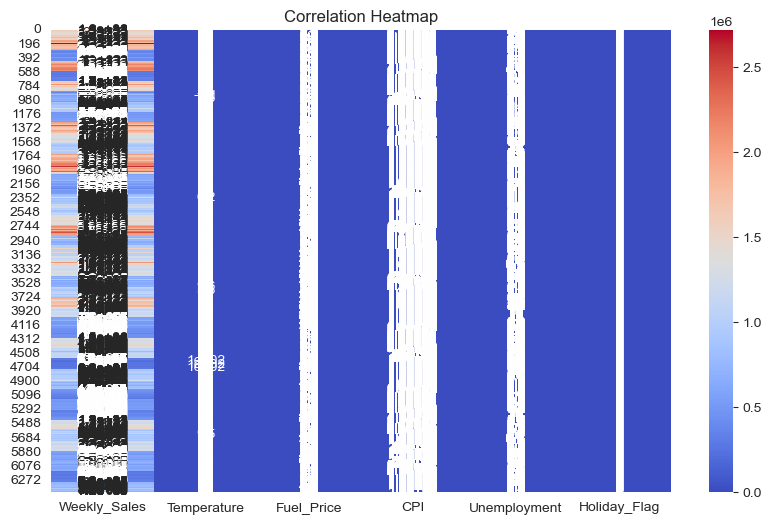

In [22]:
# =========================================
# Clean Correlation Heatmap - Focus on Numeric Factors
# =========================================

#تحديد الأعمدة المهمة فقط للتحليل
cols_to_include = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Holiday_Flag"]

# إنشاء DataFrame للأعمدة المختارة
walmart_numeric = walmart[cols_to_include]

# رسم heatmap
plt.figure(figsize=(8,6))
sns.heatmap(walmart_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Key Factors vs Weekly Sales)", fontsize=14)
plt.show()
# Save last heatmap as PNG
plt.figure(figsize=(10,6))
sns.heatmap(walmart_numeric, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("Correlation_Heatmap.png")
plt.close()




In [23]:
walmart.to_csv("cleaned_walmart",index=False)

In [ ]:
# 1. Handling Missing Values (Example)
# Suppose we introduce some missing values artificially for demonstration

walmart.loc[0:5,"Fuel_Price"] = np.nan
walmart["Fuel_Price"].fillna(walmart["Fuel_Price"].mean(), inplace=True)

walmart.head()

In [41]:
store_info = pd.DataFrame({
    "Store": [1,2,3,4],
    "Region": ["North","South","East","West"]
})
# Merge with Walmart data
walmart_merged = walmart.merge(store_info, on="Store", how="left")
walmart_merged=pd.merge(walmart1,walmart2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year,Season,Region
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010,Winter,North
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010,Winter,North
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010,Winter,North
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010,Winter,North
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010,Spring,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,28,9,2012,Autumn,NaN
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,5,10,2012,Autumn,NaN
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,12,10,2012,Autumn,NaN
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,19,10,2012,Autumn,NaN


In [21]:
# 3. Apply & Lambda
walmart["Sales_Category"] = walmart["Weekly_Sales"].apply(lambda x: "High" if x > 100000 else "Low")
walmart

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year,Season,Sales_Category
0,1,2010-02-05,1643690.90,0,42.31,3.359332,211.096358,8.106,5,2,2010,Winter,High
1,1,2010-02-12,1641957.44,1,38.51,3.359332,211.242170,8.106,12,2,2010,Winter,High
2,1,2010-02-19,1611968.17,0,39.93,3.359332,211.289143,8.106,19,2,2010,Winter,High
3,1,2010-02-26,1409727.59,0,46.63,3.359332,211.319643,8.106,26,2,2010,Winter,High
4,1,2010-03-05,1554806.68,0,46.50,3.359332,211.350143,8.106,5,3,2010,Spring,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997000,192.013558,8.684,28,9,2012,Autumn,High
6431,45,2012-10-05,733455.07,0,64.89,3.985000,192.170412,8.667,5,10,2012,Autumn,High
6432,45,2012-10-12,734464.36,0,54.47,4.000000,192.327265,8.667,12,10,2012,Autumn,High
6433,45,2012-10-19,718125.53,0,56.47,3.969000,192.330854,8.667,19,10,2012,Autumn,High


In [23]:
walmart["Adjusted_Sales"] = walmart.apply(
    lambda row: row["Weekly_Sales"] / row["CPI"],
    axis=1
)
walmart

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year,Season,Sales_Category,Adjusted_Sales
0,1,2010-02-05,1643690.90,0,42.31,3.359332,211.096358,8.106,5,2,2010,Winter,High,7786.448397
1,1,2010-02-12,1641957.44,1,38.51,3.359332,211.242170,8.106,12,2,2010,Winter,High,7772.867707
2,1,2010-02-19,1611968.17,0,39.93,3.359332,211.289143,8.106,19,2,2010,Winter,High,7629.204927
3,1,2010-02-26,1409727.59,0,46.63,3.359332,211.319643,8.106,26,2,2010,Winter,High,6671.067444
4,1,2010-03-05,1554806.68,0,46.50,3.359332,211.350143,8.106,5,3,2010,Spring,High,7356.544257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997000,192.013558,8.684,28,9,2012,Autumn,High,3714.185386
6431,45,2012-10-05,733455.07,0,64.89,3.985000,192.170412,8.667,5,10,2012,Autumn,High,3816.690948
6432,45,2012-10-12,734464.36,0,54.47,4.000000,192.327265,8.667,12,10,2012,Autumn,High,3818.825992
6433,45,2012-10-19,718125.53,0,56.47,3.969000,192.330854,8.667,19,10,2012,Autumn,High,3733.803050


In [24]:
#converts negative numbers to positive.
walmart["Weekly_Sales"] = walmart["Weekly_Sales"].apply(
    lambda x: abs(x)
)


In [25]:
#Apply Discount Rule
walmart["New_Sales"] = walmart.apply(
    lambda row: row["Weekly_Sales"] * -1.05 if row["Unemployment"] > 9 else row["Weekly_Sales"],
    axis=1
)


In [26]:
#GroupBy with Lambda
sales_range = walmart.groupby("Store")["Weekly_Sales"].agg(
    lambda x: x.max() - x.min()
)


In [27]:
#Replace Missing Values
median_unemp = walmart["Unemployment"].median()

walmart["Unemployment"] = walmart["Unemployment"].apply(
    lambda x: median_unemp if pd.isna(x) else x
)


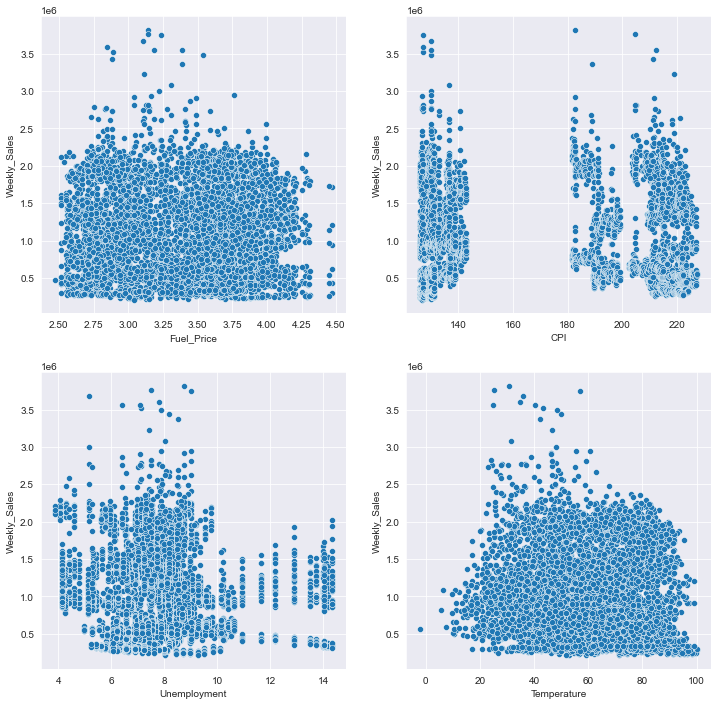

In [75]:
fig, axes = plt.subplots(2,2, figsize=(12,12))
sns.scatterplot( y="Weekly_Sales",x="Fuel_Price",data=walmart,   ax=axes[0,0])
sns.scatterplot( y="Weekly_Sales",x= "CPI",data=walmart, ax=axes[0, 1])
sns.scatterplot( y="Weekly_Sales",x= "Unemployment",data=walmart,  ax=axes[1, 0])
sns.scatterplot( y="Weekly_Sales",x= "Temperature",data=walmart,   ax=axes[1, 1])
plt.show()

form this chart we realise that store 20 has the maximum weekly sales

from this bar plot we realise that store 12,28,38 has maximum  of Unemployment

from this bar plot we realise that store 10,12,28,33,38,42 has maximum  of fuel price


In [86]:
new_data = walmart.groupby("Store")['Weekly_Sales'].sum().to_frame().reset_index()
new_data1 = walmart.groupby("Store")['Unemployment'].sum().to_frame().reset_index()
new_data2 = walmart.groupby("Store")['Fuel_Price'].sum().to_frame().reset_index()

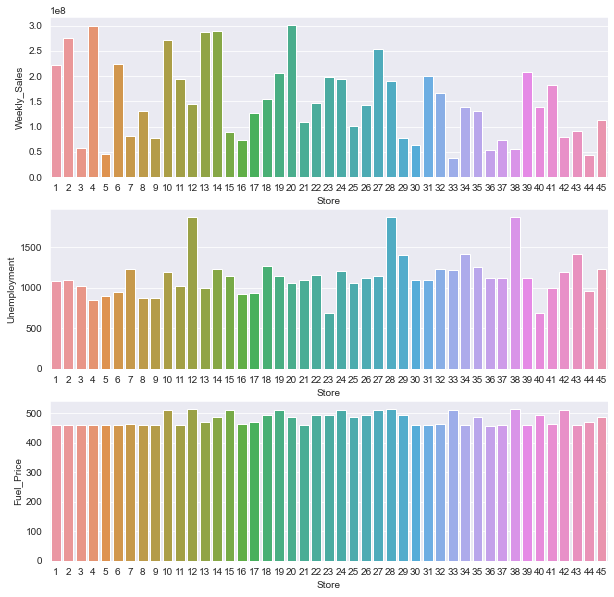

In [87]:
plt.figure(figsize = (10,10))
plt.subplot(3,1,1)
sns.barplot( y="Weekly_Sales",x="Store",data=new_data )
plt.subplot(3,1,2)
sns.barplot( y='Unemployment',x= "Store",data=new_data1)
plt.subplot(3,1,3)
sns.barplot( y='Fuel_Price',x= "Store",data=new_data2)
plt.show()

so to increase the weekly sales of this stores we can make holioday flags to encourage customers to buy 


# Pie Chart


In [78]:
flag= walmart.groupby('Holiday_Flag')["Weekly_Sales"].sum().to_frame().reset_index()
flag

,Holiday_Flag,Weekly_Sales
0,0,6.231919e+09
1,1,5.052996e+08


### from this chart we realise that non holidays has higher weekly sales than holidays 

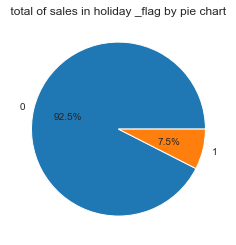

In [79]:
plt.pie (flag['Weekly_Sales'],labels =flag['Holiday_Flag'] ,autopct='%1.1f%%')
plt.title(" total of sales in holiday _flag by pie chart ")
plt.show() 

In [80]:
season= walmart.groupby('Season')["Weekly_Sales"].sum().to_frame().reset_index()
season

,Season,Weekly_Sales
0,Autumn,1.652620e+09
1,Spring,1.804507e+09
2,Summer,1.732564e+09
3,Winter,1.547528e+09


form this chart we realise that spring season has the maximum weekly sales

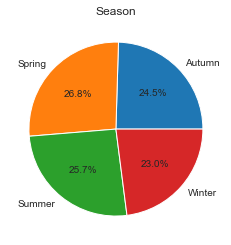

In [81]:
plt.pie (season['Weekly_Sales'],labels =season['Season'] ,autopct='%1.1f%%')
plt.title("Season")
plt.show() 

In [29]:
walmart.to_csv("walmart_clean.csv", index=False)
walmart


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year,Season,Sales_Category,Adjusted_Sales,New_Sales
0,1,2010-02-05,1643690.90,0,42.31,3.359332,211.096358,8.106,5,2,2010,Winter,High,7786.448397,1643690.90
1,1,2010-02-12,1641957.44,1,38.51,3.359332,211.242170,8.106,12,2,2010,Winter,High,7772.867707,1641957.44
2,1,2010-02-19,1611968.17,0,39.93,3.359332,211.289143,8.106,19,2,2010,Winter,High,7629.204927,1611968.17
3,1,2010-02-26,1409727.59,0,46.63,3.359332,211.319643,8.106,26,2,2010,Winter,High,6671.067444,1409727.59
4,1,2010-03-05,1554806.68,0,46.50,3.359332,211.350143,8.106,5,3,2010,Spring,High,7356.544257,1554806.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997000,192.013558,8.684,28,9,2012,Autumn,High,3714.185386,713173.95
6431,45,2012-10-05,733455.07,0,64.89,3.985000,192.170412,8.667,5,10,2012,Autumn,High,3816.690948,733455.07
6432,45,2012-10-12,734464.36,0,54.47,4.000000,192.327265,8.667,12,10,2012,Autumn,High,3818.825992,734464.36
6433,45,2012-10-19,718125.53,0,56.47,3.969000,192.330854,8.667,19,10,2012,Autumn,High,3733.803050,718125.53


# Bubble Chart

Text(0.5, 1.0, 'Bubble Chart')

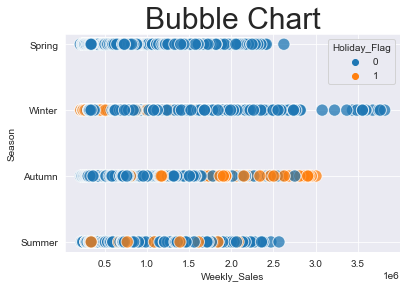

In [82]:
sns.scatterplot(data=walmart,x='Weekly_Sales',y='Season',hue="Holiday_Flag",s=150,alpha=0.75)
plt.title("Bubble Chart",size=30)

### from theis bubble chart we realize that spring season has  non holidays 
## winter season has nubmer of non holidays greater than holidays 